# Retail Sales Data Analysis

## Exploratory Data Analysis (EDA)

This project performs exploratory data analysis on a retail sales dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("retail_large_dataset.csv")

In [46]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [47]:
df.shape

(100000, 18)

In [48]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'product_price', 'quantity', 'discount_percentage', 'final_price',
       'payment_method', 'shipping_type', 'delivery_days', 'return_status'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  str           
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  str           
 3   city                 100000 non-null  str           
 4   state                100000 non-null  str           
 5   customer_segment     100000 non-null  str           
 6   order_id             100000 non-null  str           
 7   order_date           100000 non-null  datetime64[us]
 8   product_category     100000 non-null  str           
 9   product_subcategory  100000 non-null  str           
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price          10000

Statistical information

In [50]:
df.describe()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,2024-06-29 02:48:38.304000,30164.526720,2.501790,15.009890,64165.723382,5.505540
min,18.000000,2023-01-01 00:00:00,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,2023-09-30 00:00:00,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,2024-06-28 00:00:00,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,2025-03-30 00:00:00,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,2025-12-30 00:00:00,59998.000000,4.000000,30.000000,239980.000000,10.000000
std,13.852439,NaN,17139.679807,1.120058,8.953296,49969.280150,2.872868


  #### missing values

In [45]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.dtypes

customer_id                       str
age                             int64
gender                            str
city                              str
state                             str
customer_segment                  str
order_id                          str
order_date             datetime64[us]
product_category                  str
product_subcategory               str
product_price                   int64
quantity                        int64
discount_percentage             int64
final_price                   float64
payment_method                    str
shipping_type                     str
delivery_days                   int64
return_status                     str
dtype: object

In [53]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [54]:
df['order_date'].dtype

dtype('<M8[us]')

numerical columns

In [55]:
numeric_cols = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]

In [56]:
df[numeric_cols].dtypes

age                      int64
product_price            int64
quantity                 int64
discount_percentage      int64
final_price            float64
delivery_days            int64
dtype: object


##numerical data statistical summary

In [57]:
df[numeric_cols].describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


### Minimum aur maximum

In [58]:
for col in numeric_cols:
    print(col)
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print()

age
Minimum: 18
Maximum: 65

product_price
Minimum: 500
Maximum: 59998

quantity
Minimum: 1
Maximum: 4

discount_percentage
Minimum: 0
Maximum: 30

final_price
Minimum: 357.0
Maximum: 239980.0

delivery_days
Minimum: 1
Maximum: 10



## Skewness

In [59]:
df[numeric_cols].skew()

age                   -0.004988
product_price          0.003249
quantity              -0.003067
discount_percentage   -0.003597
final_price            0.934747
delivery_days          0.002270
dtype: float64

## Kurtosis

In [60]:
df[numeric_cols].kurtosis()

age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64

## Age distribution

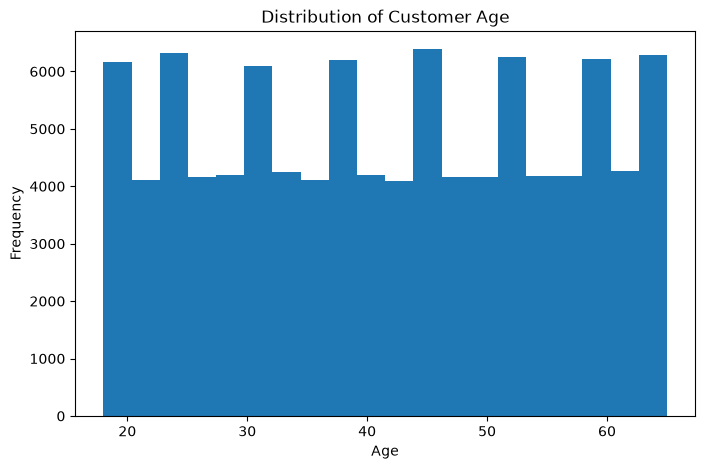

In [61]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Age')

plt.show()

## Age Boxplot

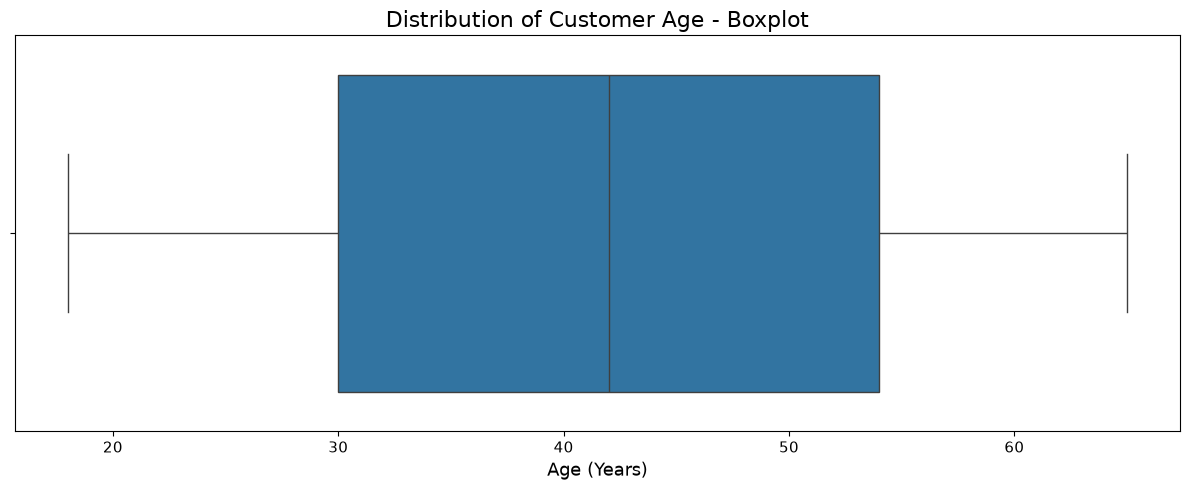

In [62]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['age'])
plt.title('Distribution of Customer Age - Boxplot', fontsize=16)
plt.xlabel('Age (Years)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Product price histrogram

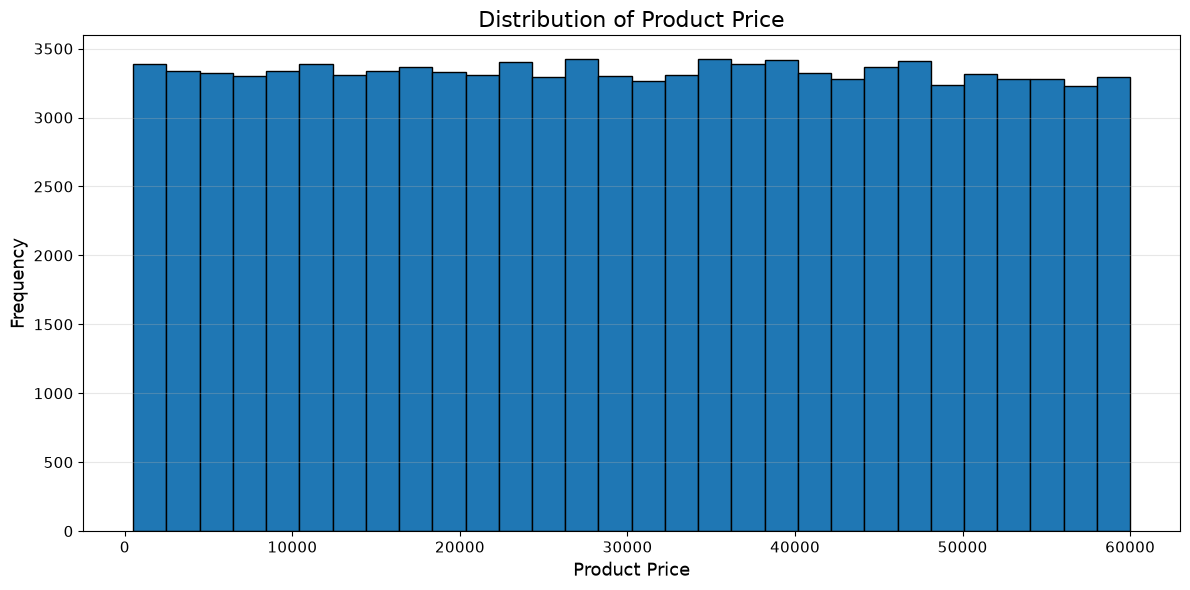

In [63]:
plt.figure(figsize=(12, 6))
plt.hist(
    df['product_price'],
    bins=30,
    edgecolor='black')
plt.title('Distribution of Product Price', fontsize=16)
plt.xlabel('Product Price', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Product price boxplot

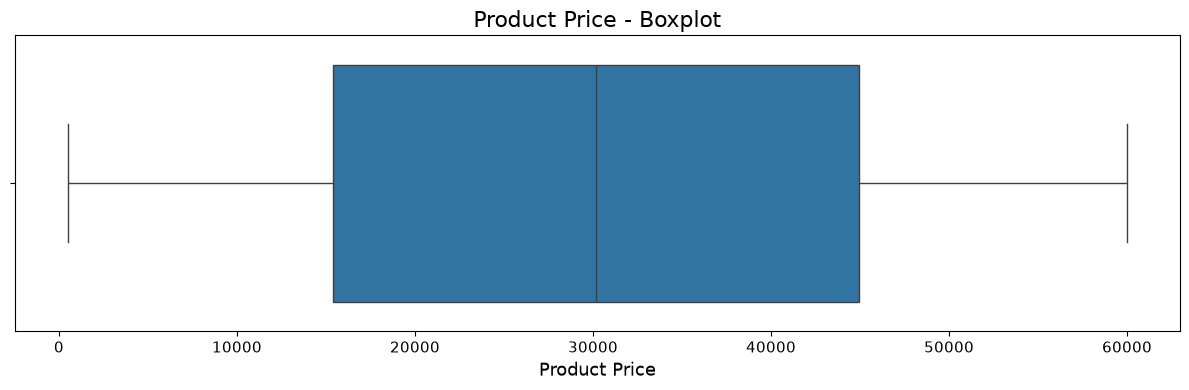

In [64]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['product_price'])
plt.title('Product Price - Boxplot', fontsize=16)
plt.xlabel('Product Price', fontsize=13)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

# Quantity Histrogram

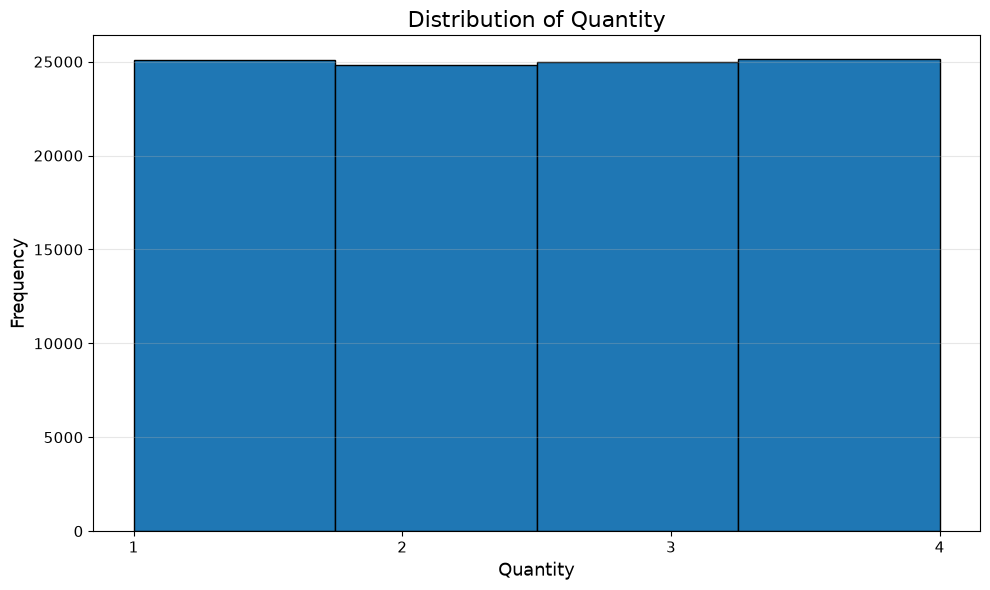

In [65]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['quantity'],
    bins=4,
    edgecolor='black')
plt.title('Distribution of Quantity', fontsize=16)
plt.xlabel('Quantity', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(
    sorted(df['quantity'].unique()),
    fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Discount Percentage Histrogram

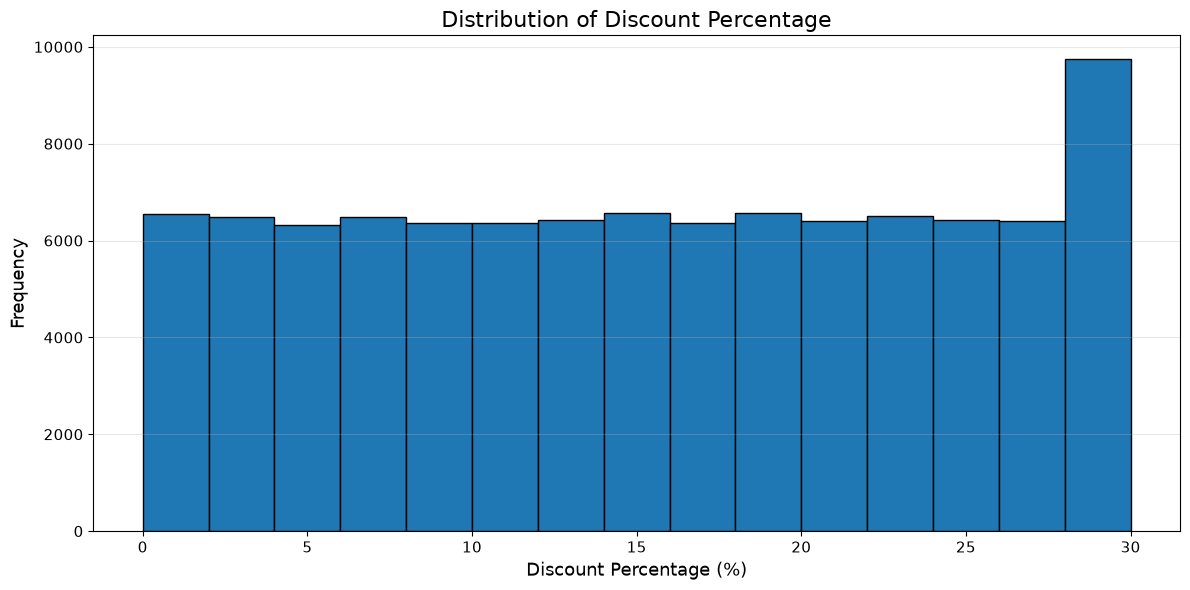

In [66]:
plt.figure(figsize=(12, 6))
plt.hist(
    df['discount_percentage'],
    bins=15,
    edgecolor='black')
plt.title('Distribution of Discount Percentage', fontsize=16)
plt.xlabel('Discount Percentage (%)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Final price histogram

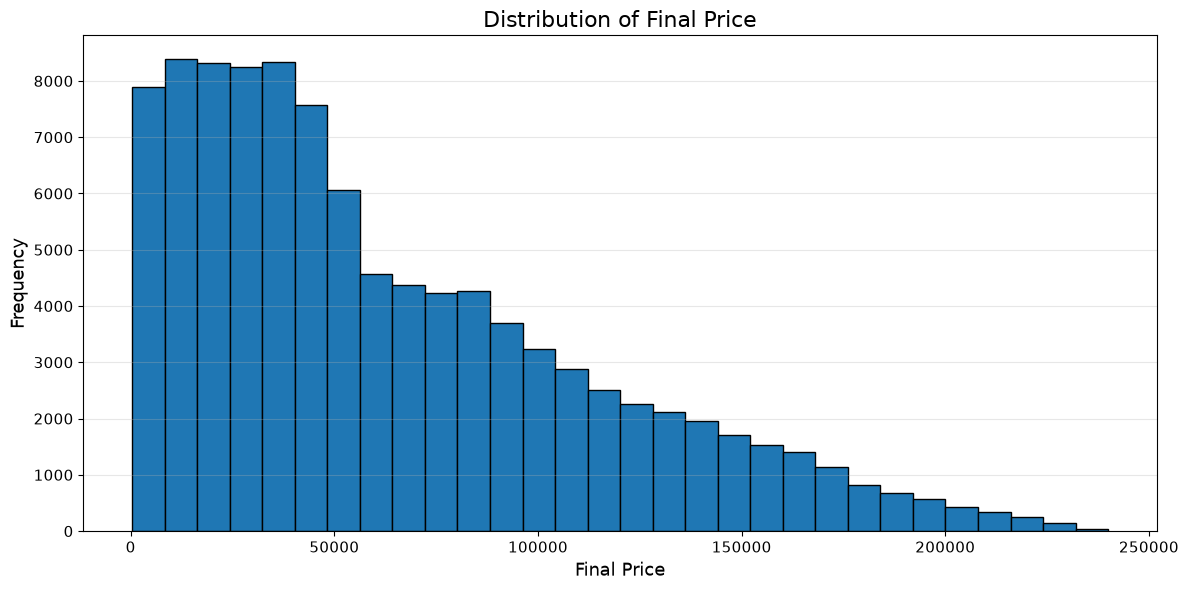

In [67]:
plt.figure(figsize=(12, 6))

plt.hist(
    df['final_price'],
    bins=30,
    edgecolor='black')
plt.title('Distribution of Final Price', fontsize=16)
plt.xlabel('Final Price', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Final price Boxplot

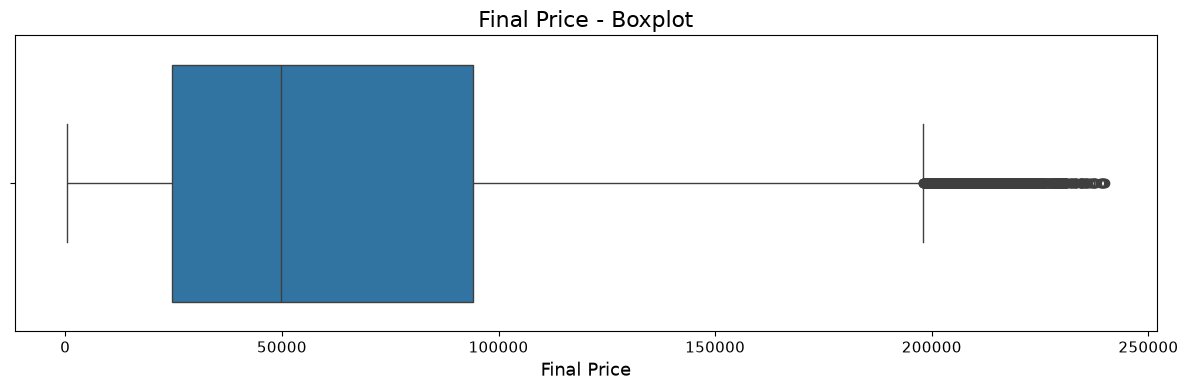

In [68]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['final_price'])
plt.title('Final Price - Boxplot', fontsize=16)
plt.xlabel('Final Price', fontsize=13)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

# Categorical Analysis

# Gender distribution

In [69]:
df['gender'].value_counts()

gender
Male      50111
Female    49889
Name: count, dtype: int64

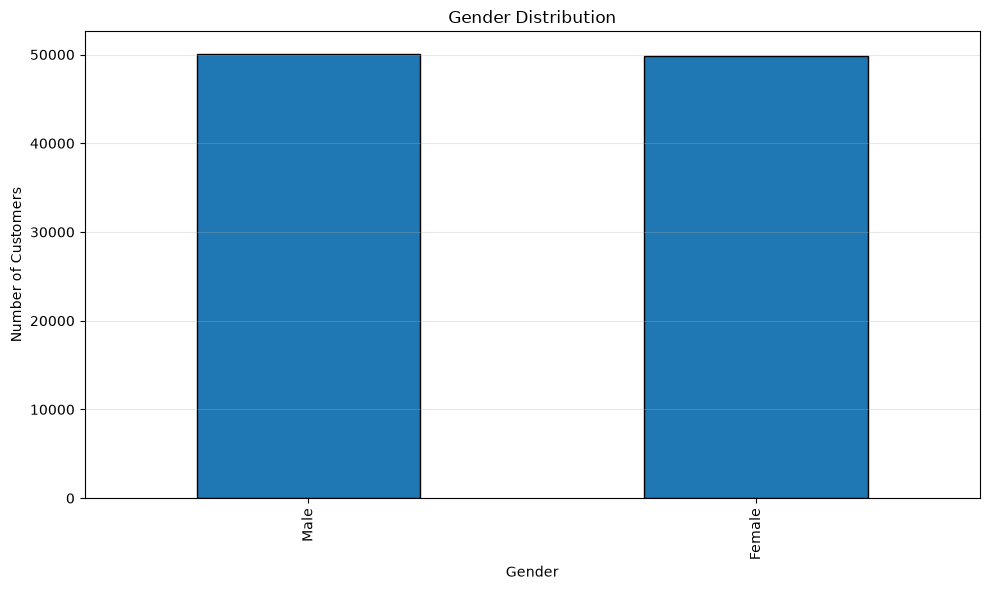

In [70]:
plt.figure(figsize=(10,6))
df['gender'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Customer Segment

In [71]:
df['customer_segment'].value_counts()

customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64

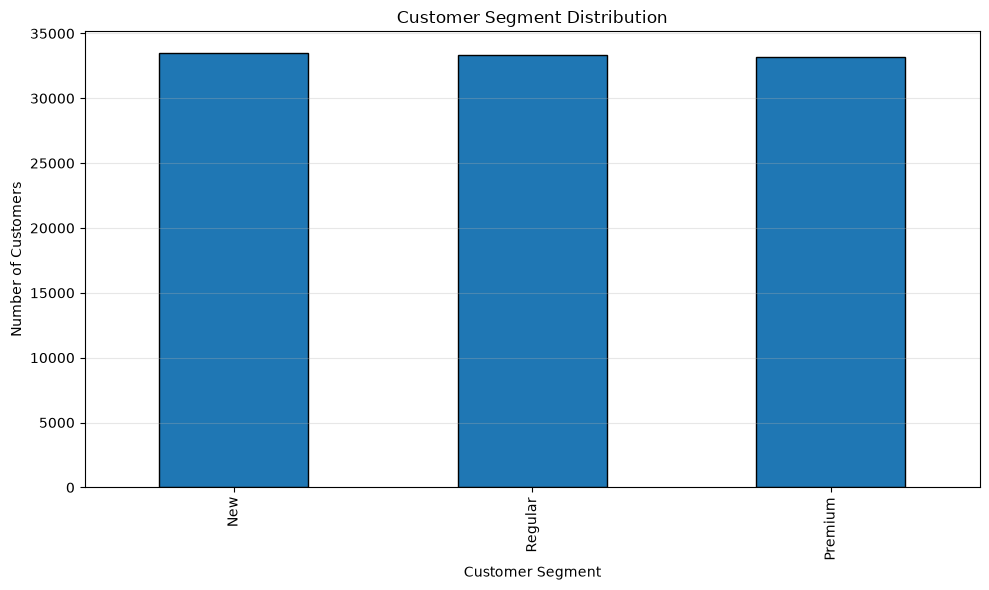

In [72]:
plt.figure(figsize=(10,6))
df['customer_segment'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Product Category

In [73]:
df['product_category'].value_counts()

product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64

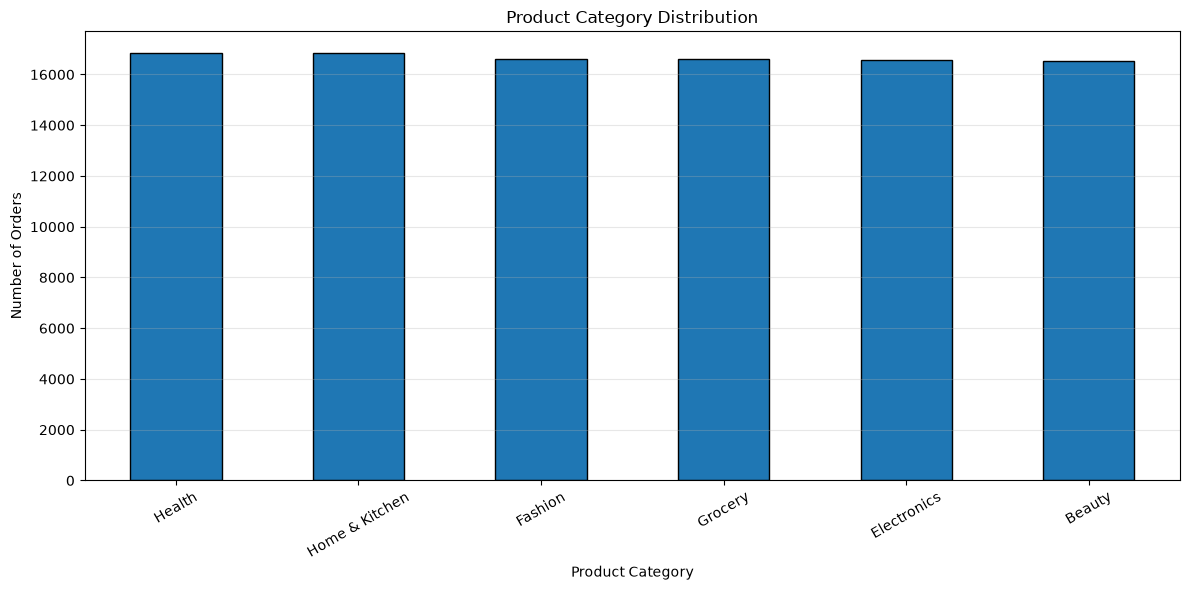

In [74]:
plt.figure(figsize=(12,6))
df['product_category'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Product Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Payment Method

In [75]:
df['payment_method'].value_counts()

payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64

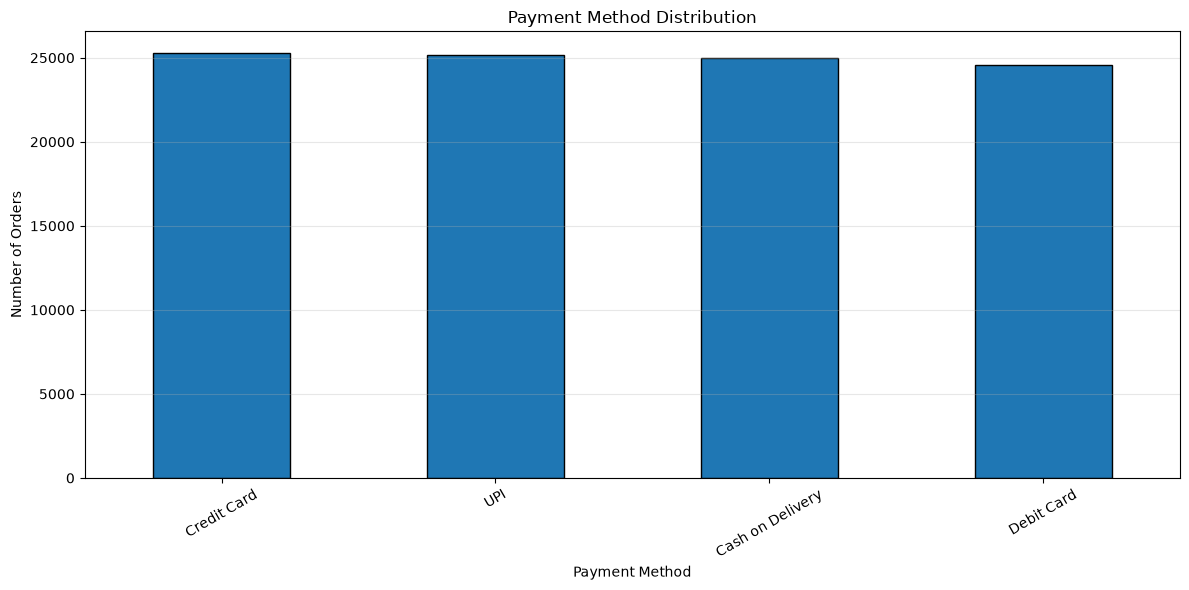

In [76]:
plt.figure(figsize=(12,6))
df['payment_method'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Shipping Type

In [77]:
df['shipping_type'].value_counts()

shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64

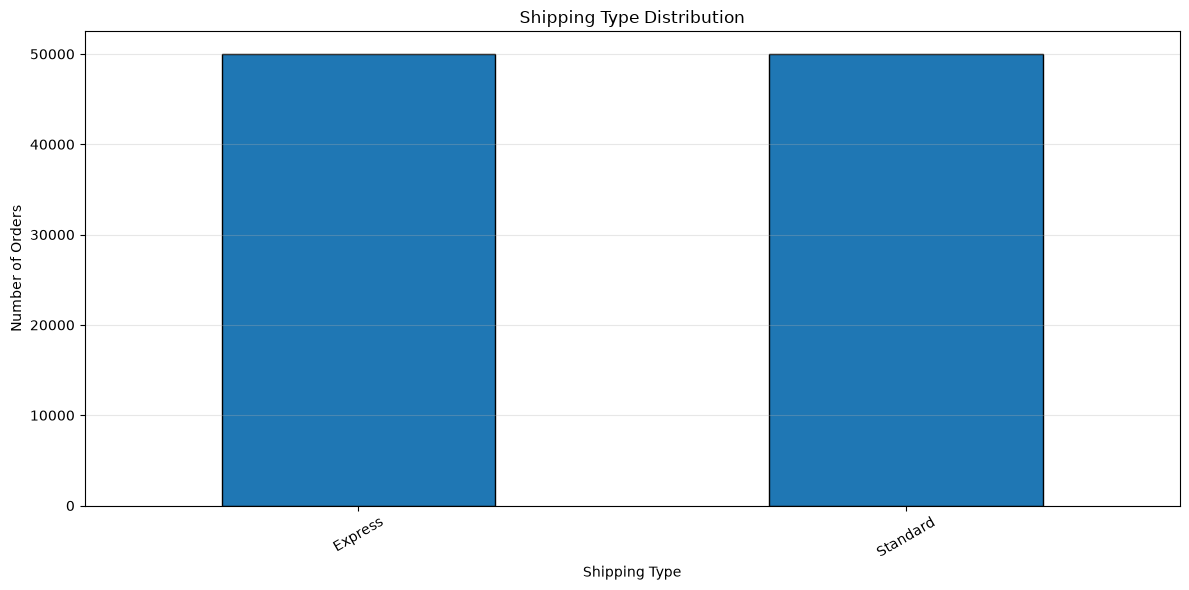

In [78]:
plt.figure(figsize=(12,6))
df['shipping_type'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Shipping Type Distribution')
plt.xlabel('Shipping Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Return status

In [79]:
df['return_status'].value_counts()

return_status
No     85189
Yes    14811
Name: count, dtype: int64

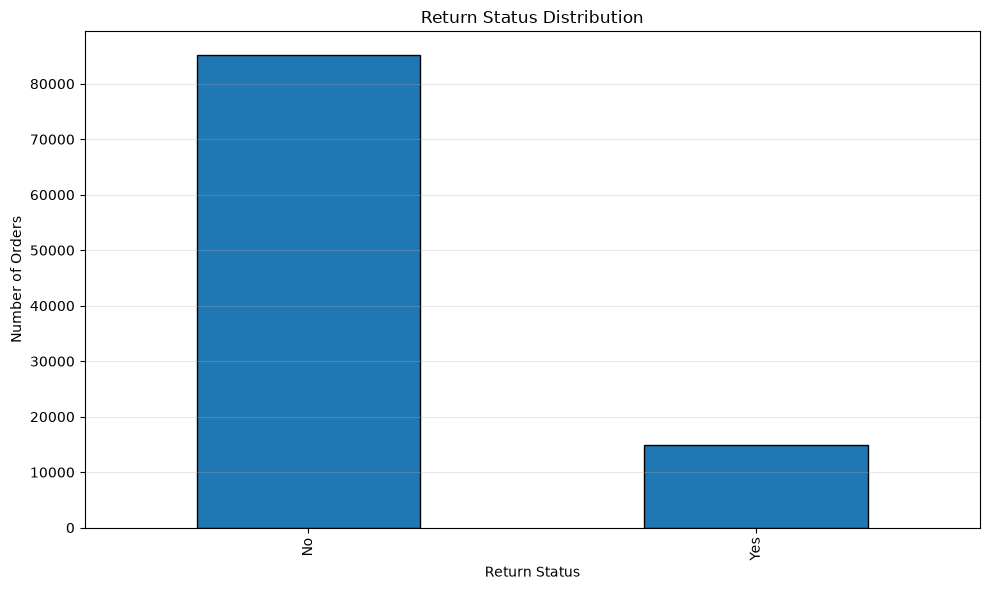

In [80]:
plt.figure(figsize=(10,6))
df['return_status'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Return Status Distribution')
plt.xlabel('Return Status')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Product subcategory

In [81]:
df['product_subcategory'].value_counts()

product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses            5477
Perfume           5423
Jeans             4278
Headphones        4265
Blender           4255
Cookware          4219
Vacuum Cleaner    4199
Smartphone        4198
Microwave         4175
Shoes             4145
Men T-Shirt       4132
Tablet            4070
Women Dress       4058
Laptop            4043
Name: count, dtype: int64

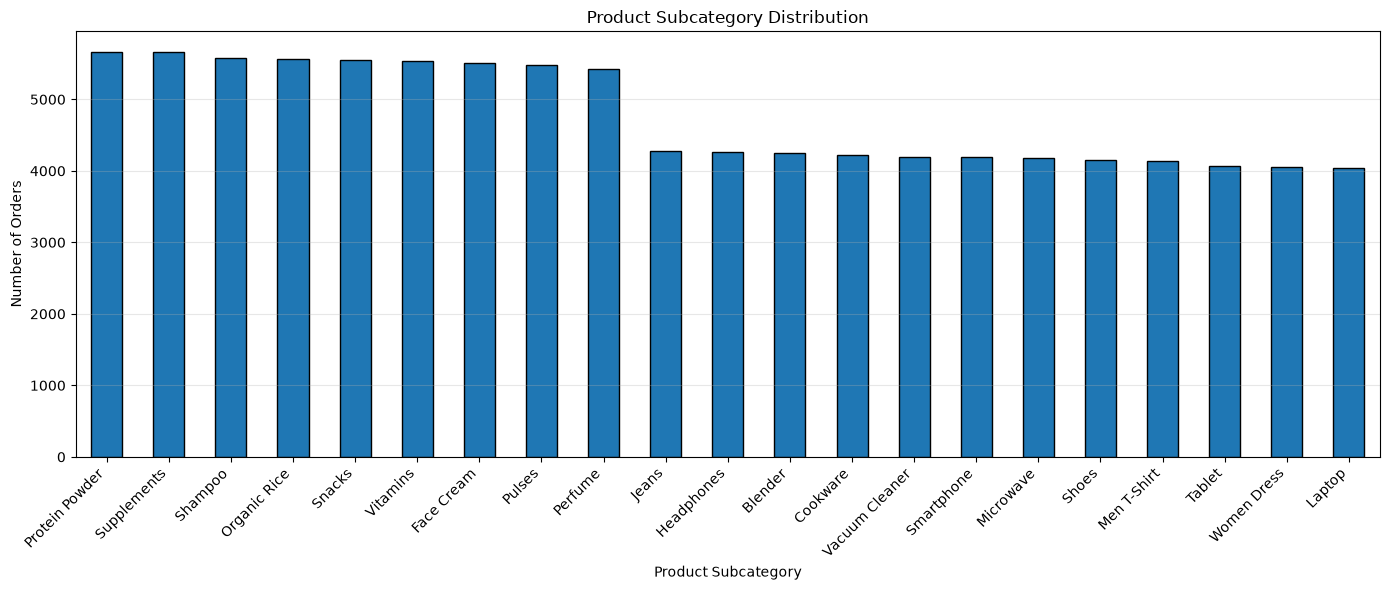

In [82]:
plt.figure(figsize=(14,6))
df['product_subcategory'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Product Subcategory Distribution')
plt.xlabel('Product Subcategory')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# OUTLIER DETECTION

In [83]:
## IQR Method

In [126]:
IQR = Q3 - Q1       

In [90]:
lower limit = Q1 - 1.5 * IQR
upper limit = Q3 + 1.5 * IQR

SyntaxError: invalid syntax (1434288818.py, line 1)

# Product price outilers

In [91]:
Q1 = df['product_price'].quantile(0.25)
Q3 = df['product_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

Q1: 15375.0
Q3: 44957.0
IQR: 29582.0
Lower Limit: -28998.0
Upper Limit: 89330.0


# Outliers numbers

In [92]:
outliers = df[
    (df['product_price'] < lower) |
    (df['product_price'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


# View the outliers

In [93]:
outliers[['product_price']].head(10)

,product_price


# Product price Boxplor

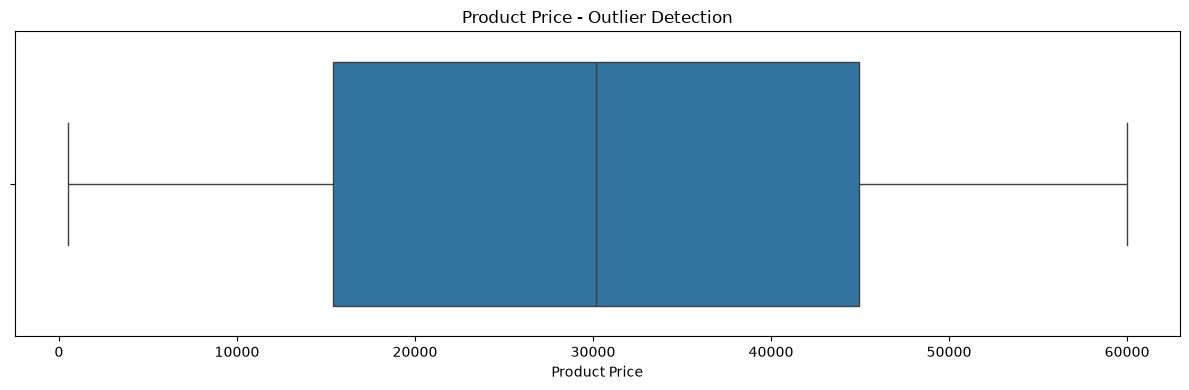

In [94]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['product_price'])
plt.title('Product Price - Outlier Detection')
plt.xlabel('Product Price')
plt.tight_layout()
plt.show()

# Z-Score method 

In [95]:
from scipy.stats import zscore

z_scores = zscore(df['product_price'])

print(z_scores[:10])

[ 0.49554693 -0.4493996   1.5424212  -0.23375855  0.06274788 -0.33650311
 -0.88237368 -0.94795283  0.17161861 -0.3129903 ]


# Z-Score outilers count

In [96]:
outliers_z = df[abs(z_scores) > 3]

print("Number of Z-Score Outliers:", len(outliers_z))

Number of Z-Score Outliers: 0


# View Z_score outliers

In [97]:
outliers_z[['product_price']].head(10)

,product_price


# Z-score outlier Visualization

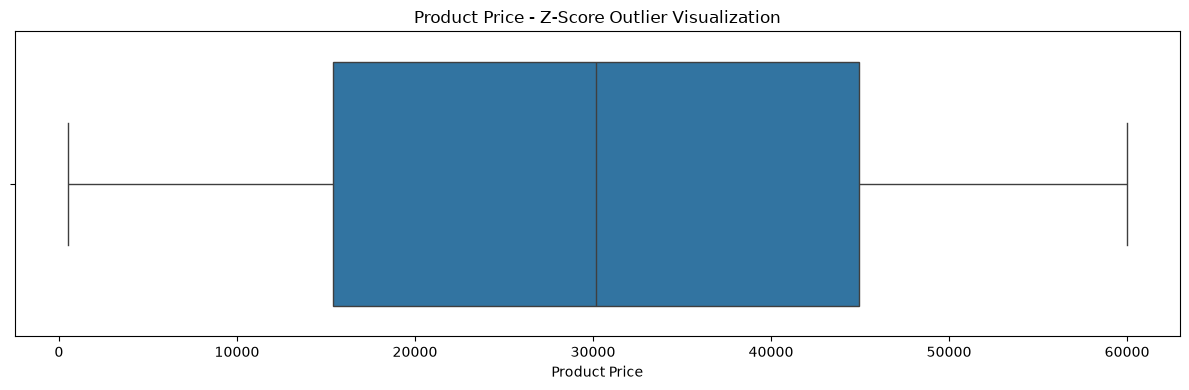

In [98]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df['product_price'])

plt.title('Product Price - Z-Score Outlier Visualization')
plt.xlabel('Product Price')

plt.tight_layout()
plt.show()

# Correlation matrix 

In [99]:
correlation = df[numeric_cols].corr()

correlation

,age,product_price,quantity,discount_percentage,final_price,delivery_days
age,1.000000,-0.000814,-0.000129,-0.004035,-0.000823,-0.003954
product_price,-0.000814,1.000000,0.000950,-0.002886,0.730757,0.001554
quantity,-0.000129,0.000950,1.000000,-0.003579,0.575303,0.004017
discount_percentage,-0.004035,-0.002886,-0.003579,1.000000,-0.137332,-0.000453
final_price,-0.000823,0.730757,0.575303,-0.137332,1.000000,0.003789
delivery_days,-0.003954,0.001554,0.004017,-0.000453,0.003789,1.000000


# Correlation heatmap

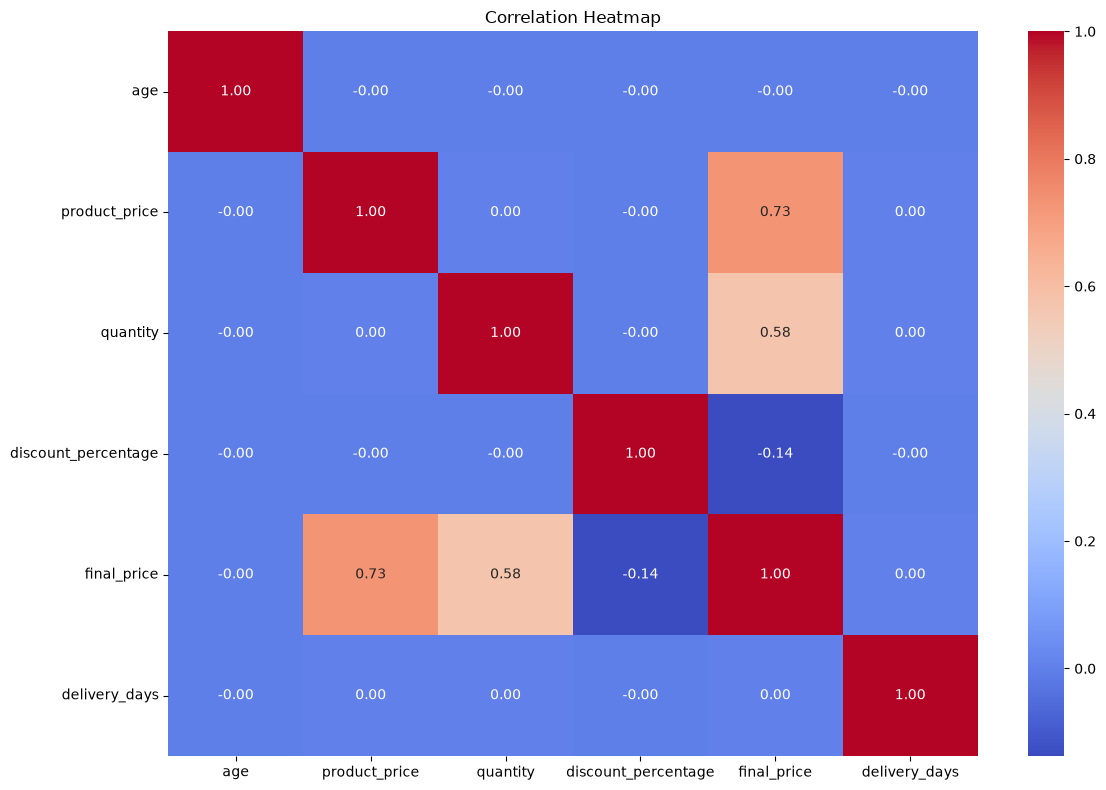

In [125]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Univariate Analysis

# Product price distribution

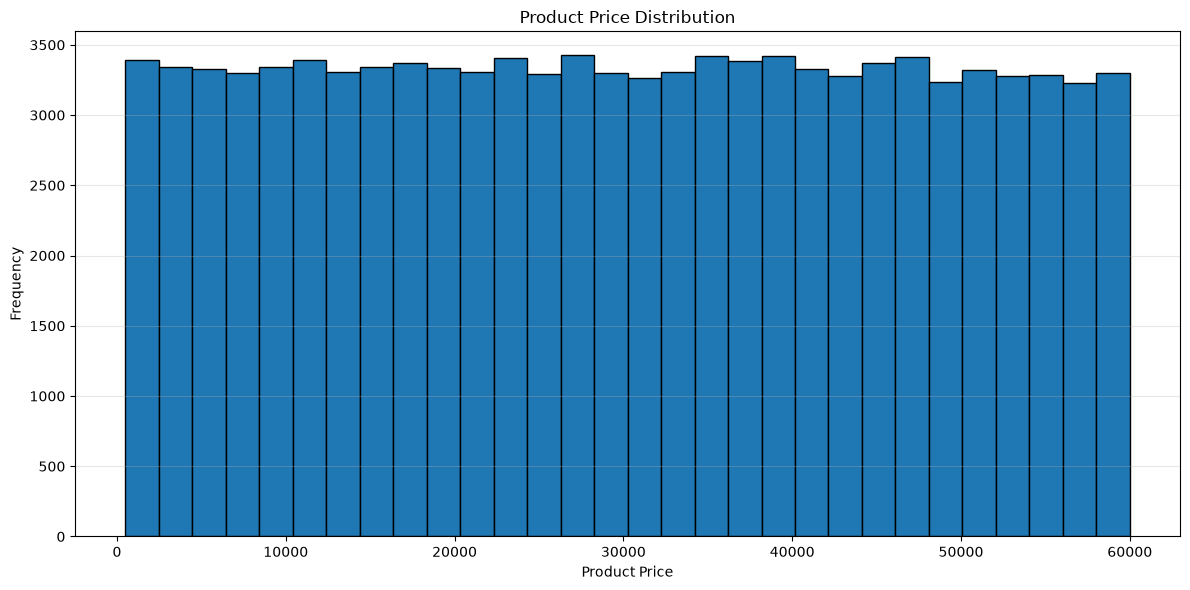

In [100]:
plt.figure(figsize=(12,6))

plt.hist(df['product_price'], bins=30, edgecolor='black')

plt.title('Product Price Distribution')
plt.xlabel('Product Price')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Age distribution

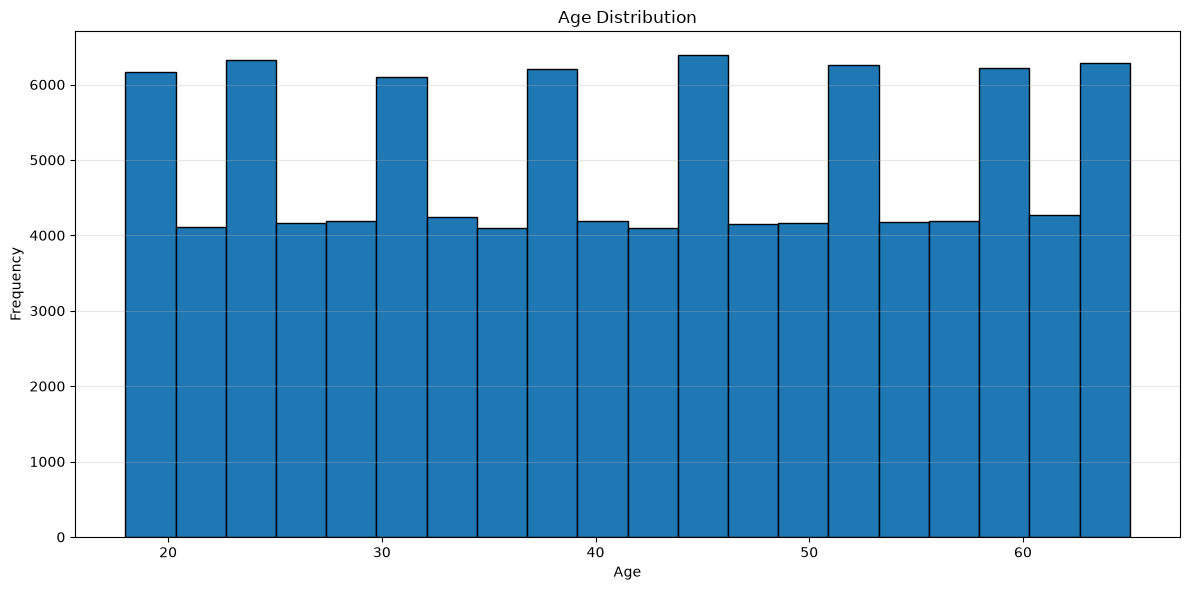

In [101]:
plt.figure(figsize=(12,6))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Quantity distribution

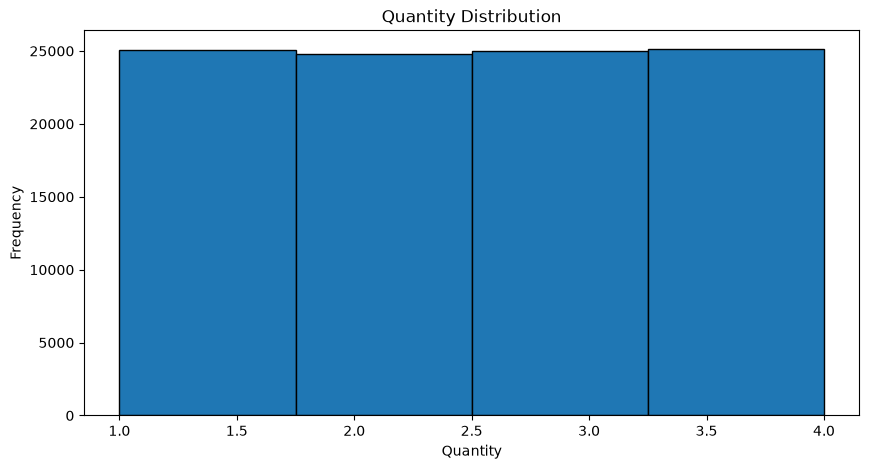

In [102]:
plt.figure(figsize=(10,5))
plt.hist(df['quantity'], bins=4, edgecolor='black')
plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

# Discount Distribution

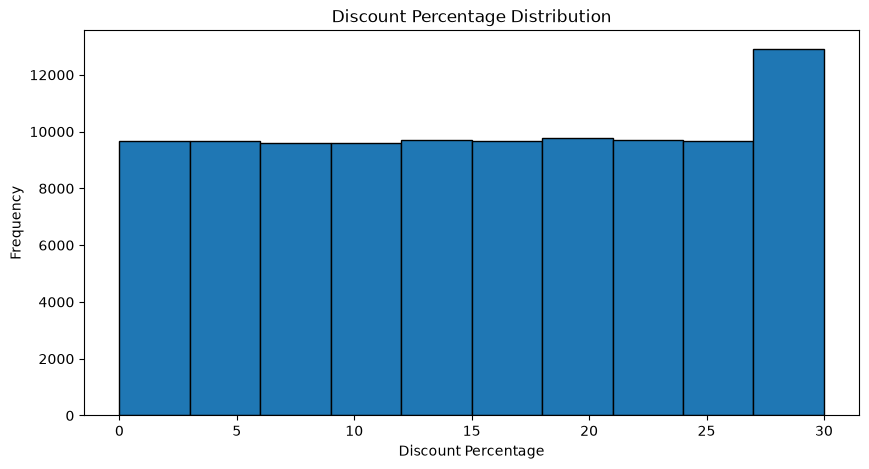

In [103]:
plt.figure(figsize=(10,5))
plt.hist(df['discount_percentage'], bins=10, edgecolor='black')
plt.title('Discount Percentage Distribution')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.show()

# Final price distribution

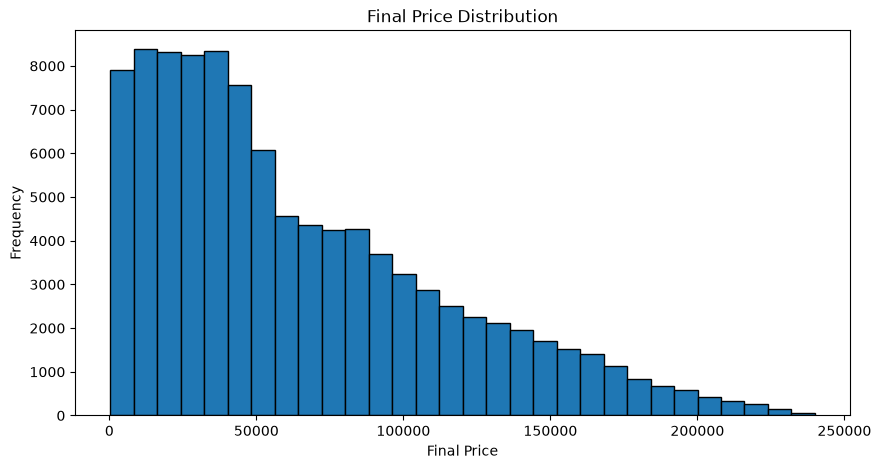

In [104]:
plt.figure(figsize=(10,5))
plt.hist(df['final_price'], bins=30, edgecolor='black')
plt.title('Final Price Distribution')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.show()

# Delivery day distribution

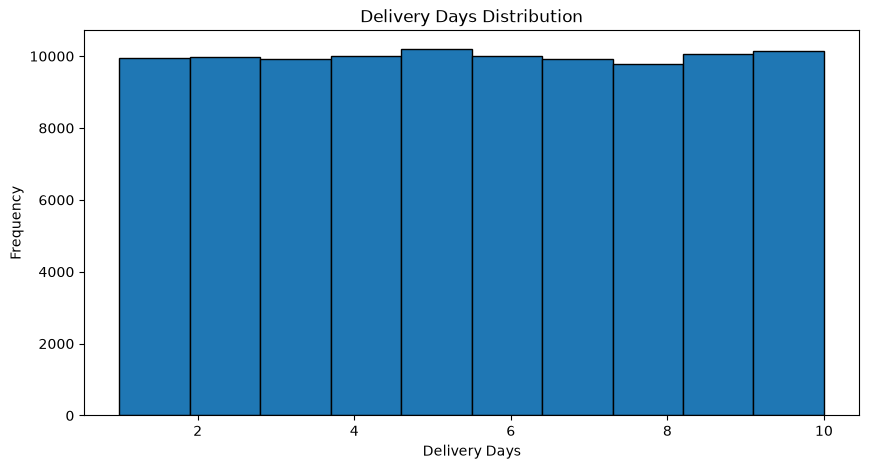

In [105]:
plt.figure(figsize=(10,5))
plt.hist(df['delivery_days'], bins=10, edgecolor='black')
plt.title('Delivery Days Distribution')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')
plt.show()

# Bivariate Analysis

# Product price VS Final price

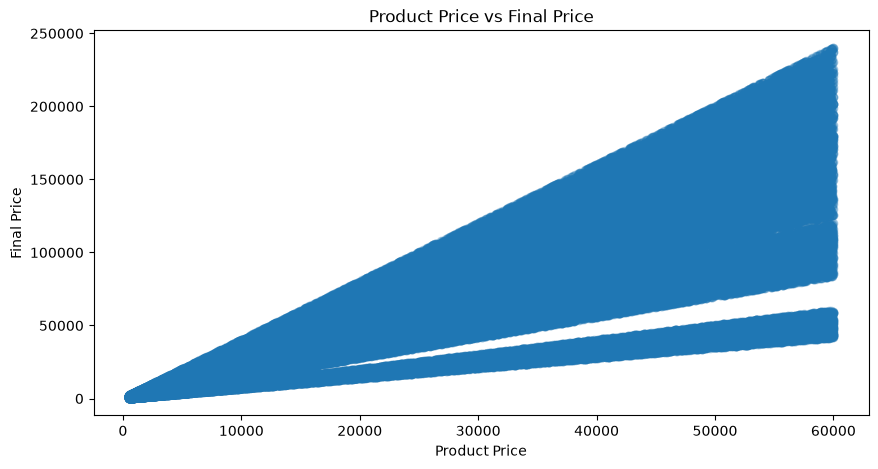

In [106]:
plt.figure(figsize=(10,5))
plt.scatter(df['product_price'], df['final_price'], alpha=0.3)
plt.title('Product Price vs Final Price')
plt.xlabel('Product Price')
plt.ylabel('Final Price')
plt.show()

# Quantity VS final price 

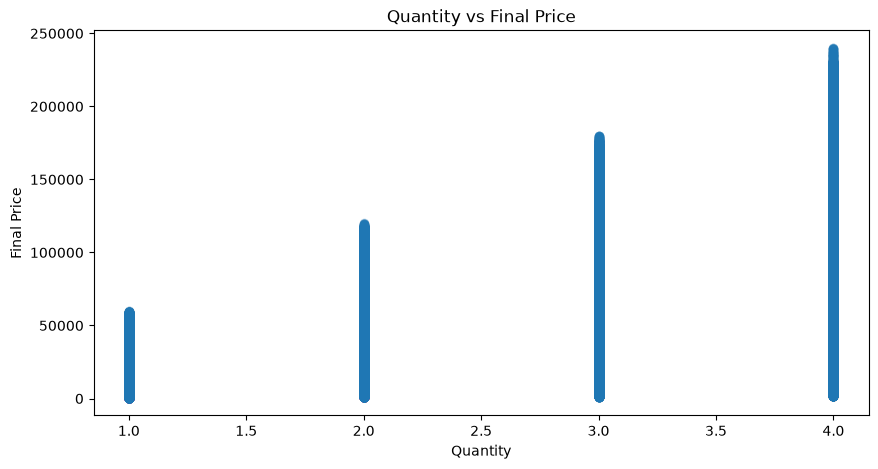

In [107]:
plt.figure(figsize=(10,5))
plt.scatter(df['quantity'], df['final_price'], alpha=0.3)
plt.title('Quantity vs Final Price')
plt.xlabel('Quantity')
plt.ylabel('Final Price')
plt.show()

# Discount vs Final price 

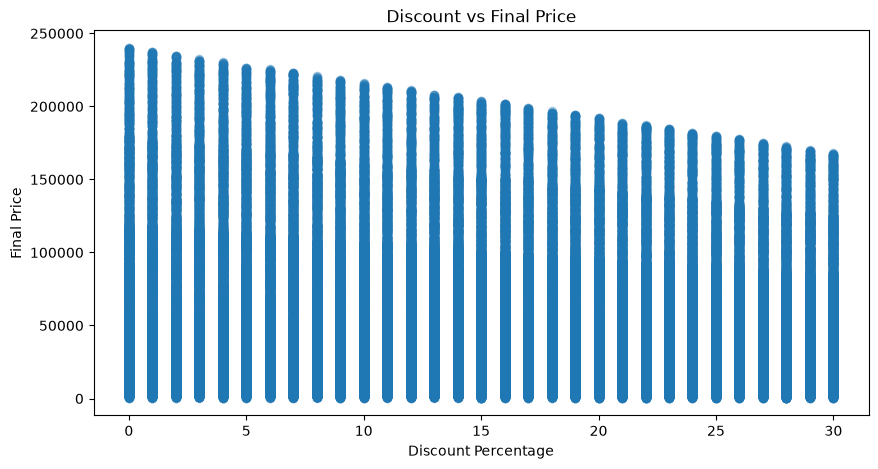

In [108]:
plt.figure(figsize=(10,5))
plt.scatter(df['discount_percentage'], df['final_price'], alpha=0.3)
plt.title('Discount vs Final Price')
plt.xlabel('Discount Percentage')
plt.ylabel('Final Price')
plt.show()

# Age vs Final price 

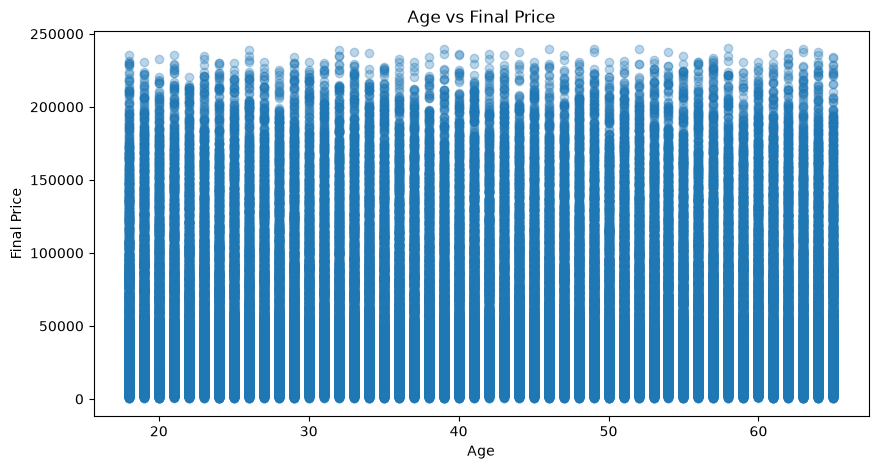

In [109]:
plt.figure(figsize=(10,5))
plt.scatter(df['age'], df['final_price'], alpha=0.3)
plt.title('Age vs Final Price')
plt.xlabel('Age')
plt.ylabel('Final Price')
plt.show()

# product category vs final price

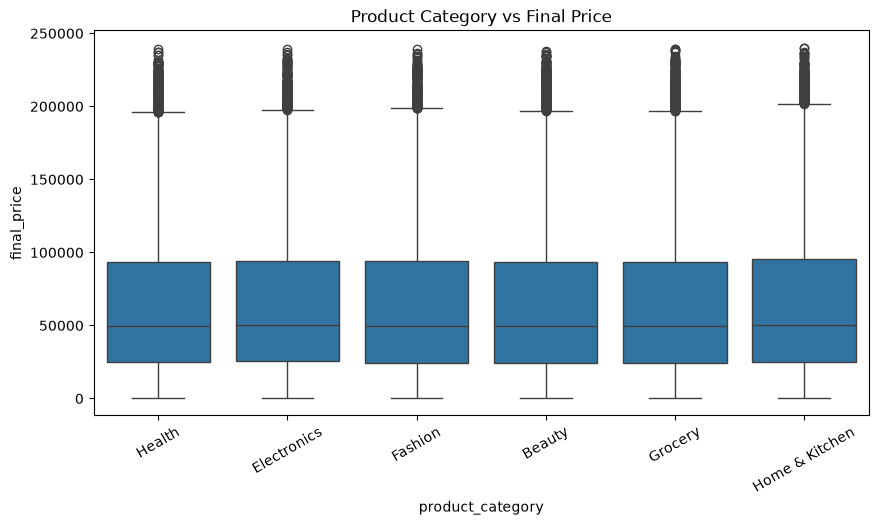

In [110]:
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='final_price', data=df)
plt.title('Product Category vs Final Price')
plt.xticks(rotation=30)
plt.show()

# Gender VS final price 

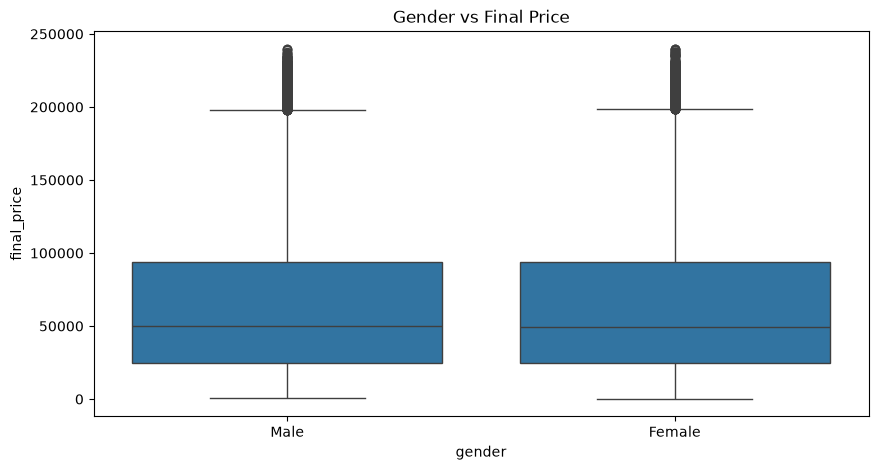

In [111]:
plt.figure(figsize=(10,5))
sns.boxplot(x='gender', y='final_price', data=df)
plt.title('Gender vs Final Price')
plt.show()

# Payment method vs final price

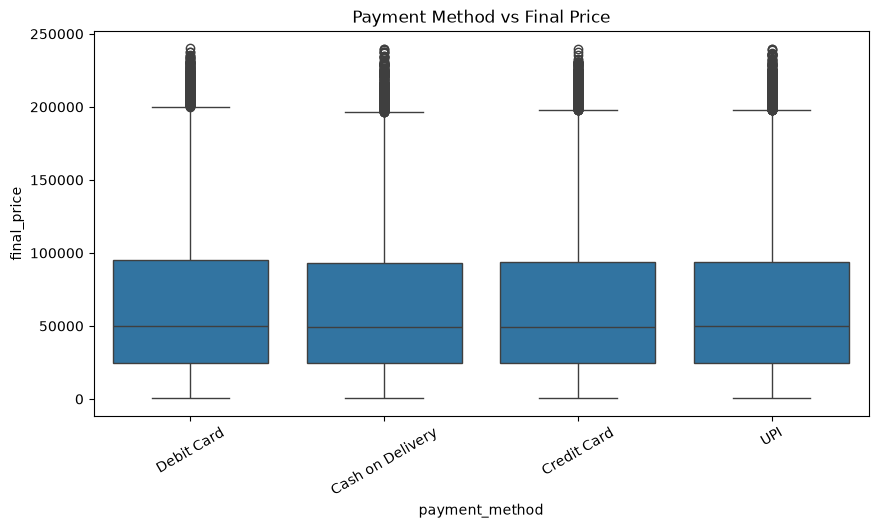

In [112]:
plt.figure(figsize=(10,5))
sns.boxplot(x='payment_method', y='final_price', data=df)
plt.title('Payment Method vs Final Price')
plt.xticks(rotation=30)
plt.show()

# Shipping Type VS final price

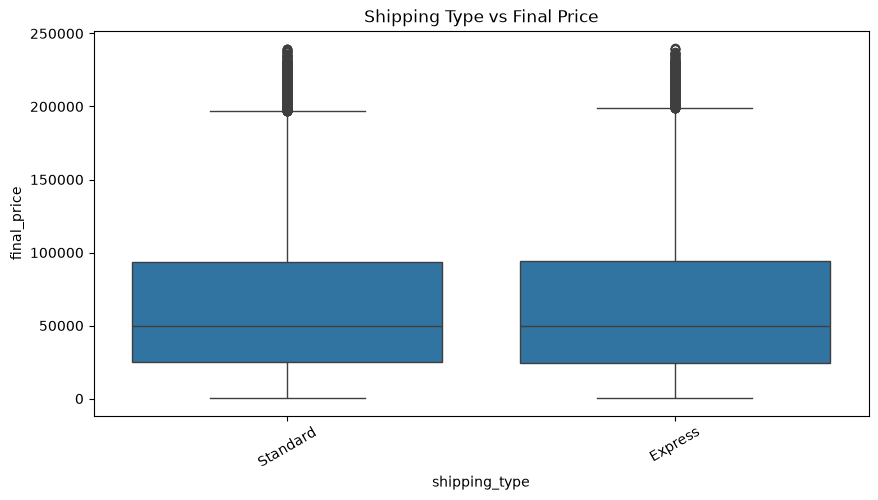

In [113]:
plt.figure(figsize=(10,5))
sns.boxplot(x='shipping_type', y='final_price', data=df)
plt.title('Shipping Type vs Final Price')
plt.xticks(rotation=30)
plt.show()

# MULTIVARIATE ANALYSIS

## Multiple numerical variables 

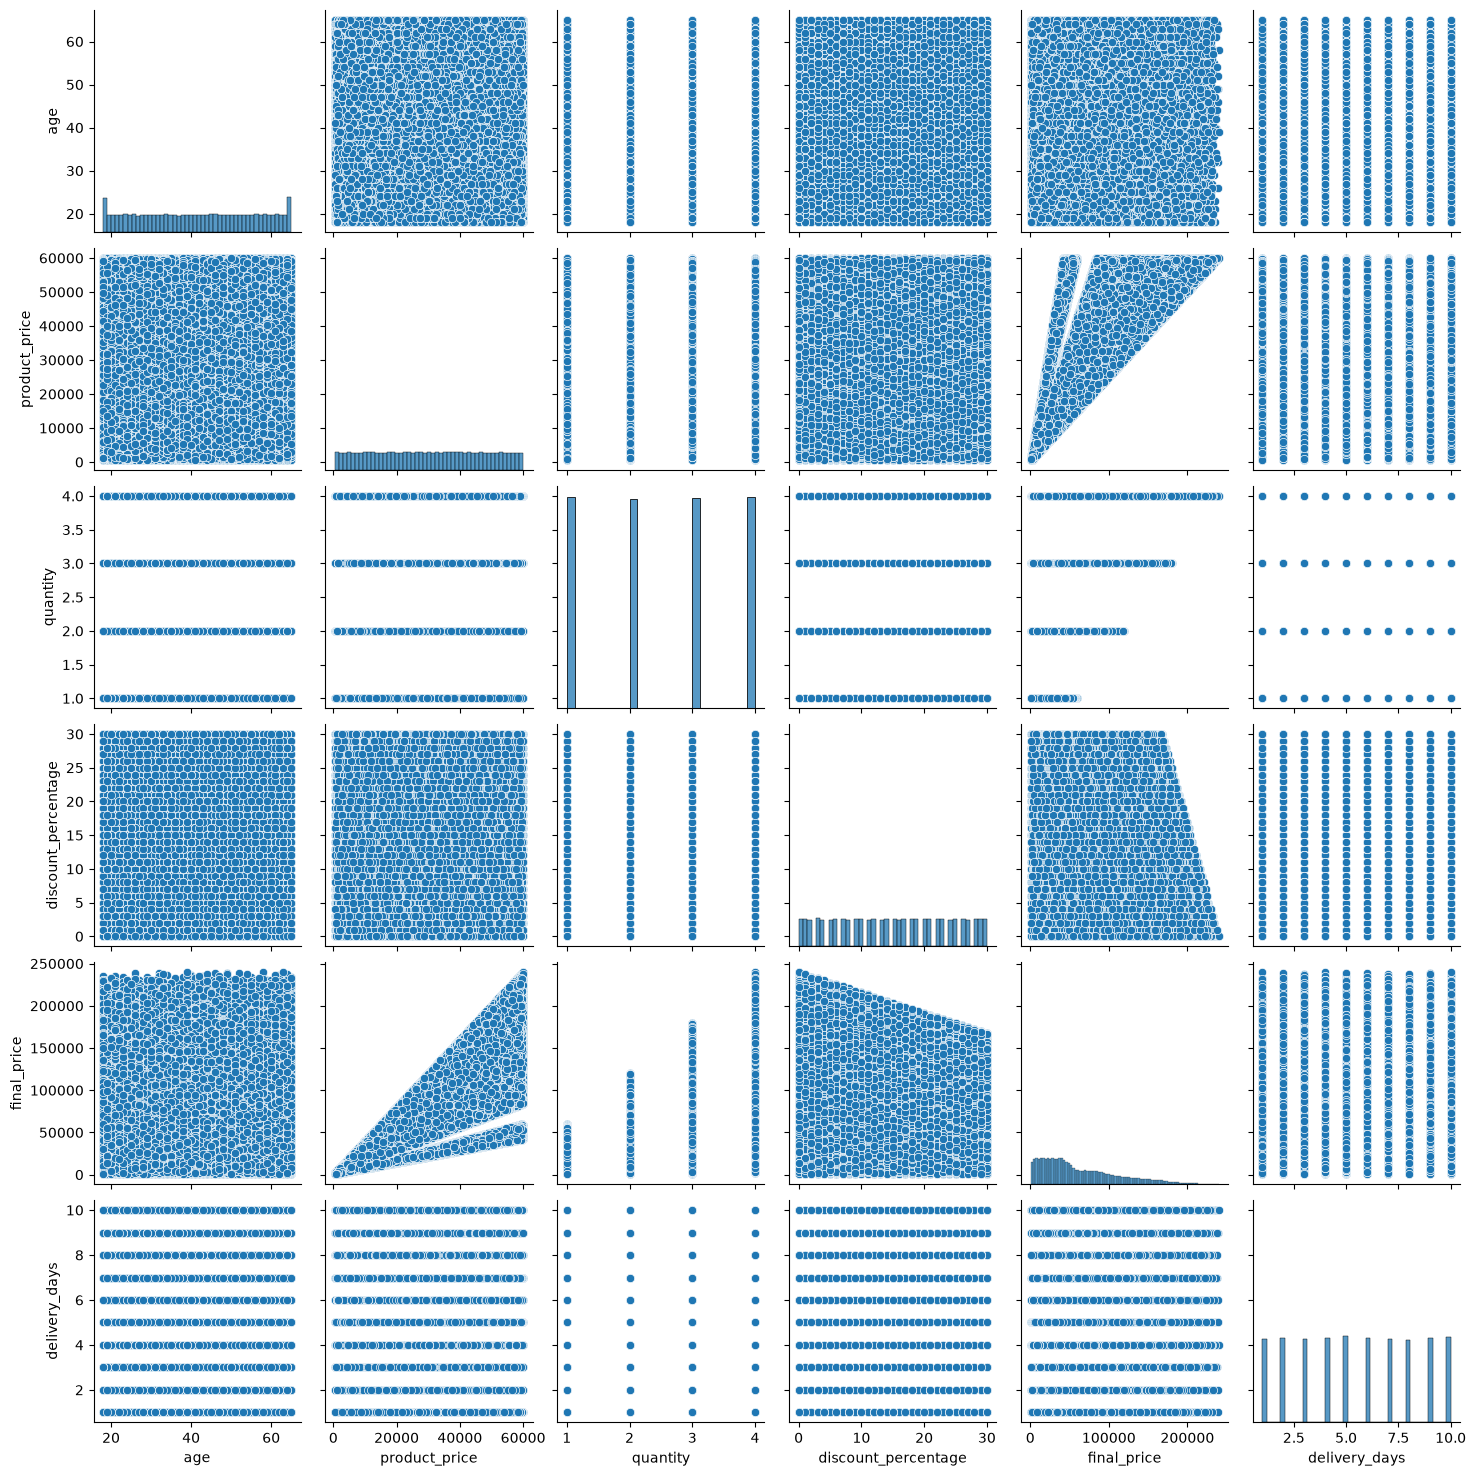

In [114]:
sns.pairplot(df[numeric_cols])
plt.show()

# Category, Gender final price

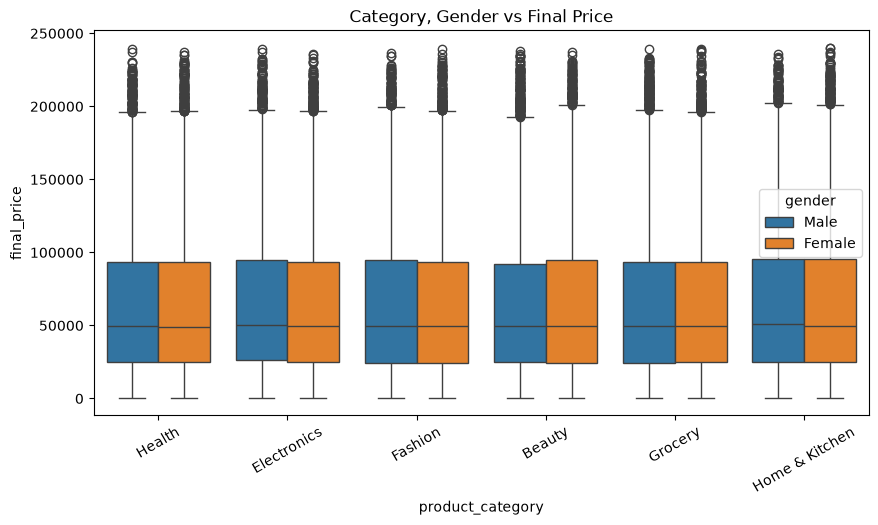

In [115]:
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='final_price', hue='gender', data=df)
plt.title('Category, Gender vs Final Price')
plt.xticks(rotation=30)
plt.show()

# Customer segment, Payment method & final price

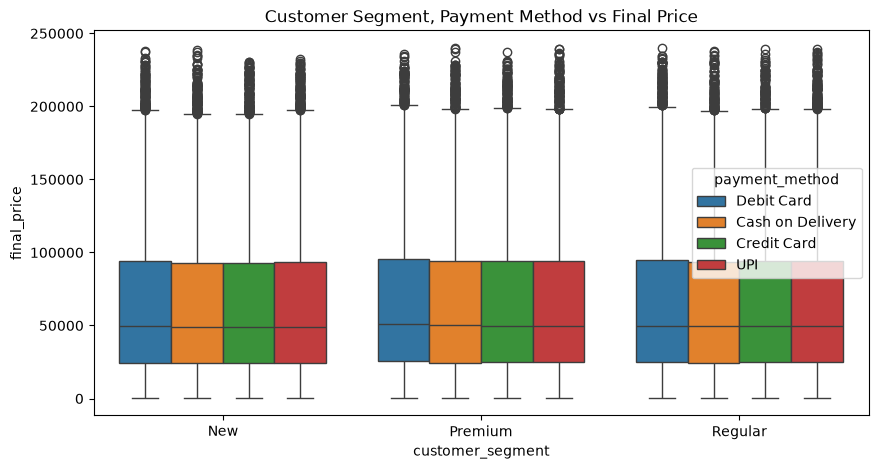

In [116]:
plt.figure(figsize=(10,5))
sns.boxplot(x='customer_segment', y='final_price', hue='payment_method', data=df)
plt.title('Customer Segment, Payment Method vs Final Price')
plt.show()

# Age, Gender & Final price

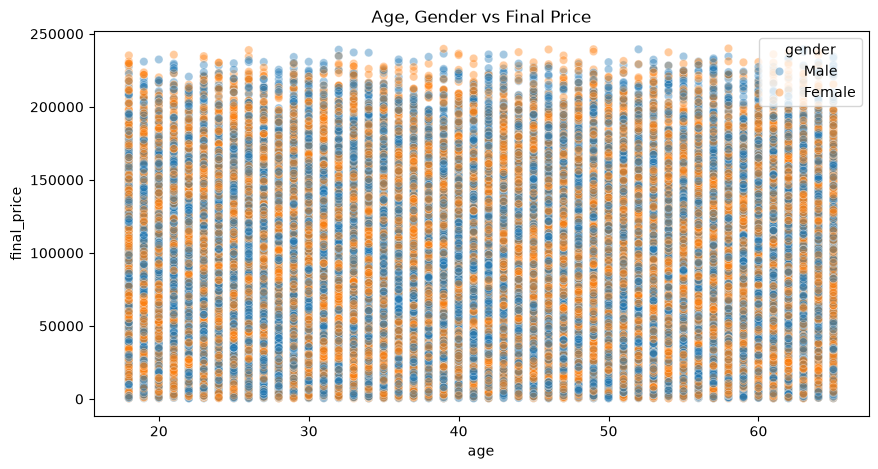

In [117]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='age', y='final_price', hue='gender', data=df, alpha=0.4)
plt.title('Age, Gender vs Final Price')
plt.show()

# Delivery Days Shipping Type & final price

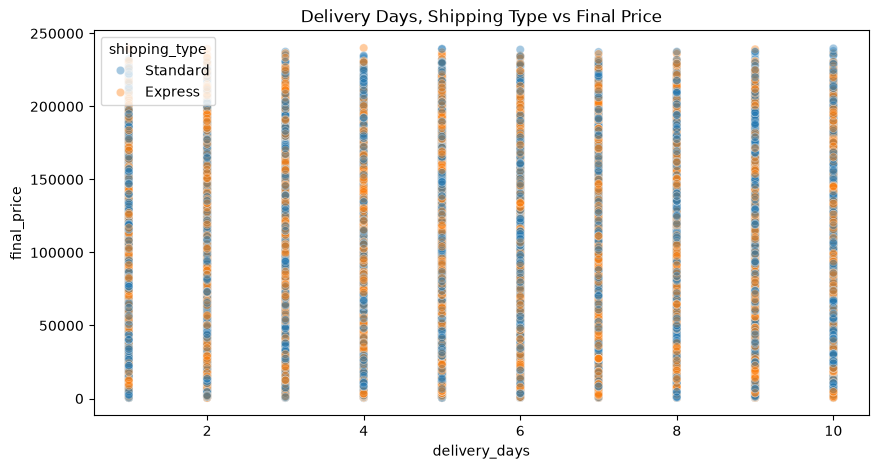

In [118]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='delivery_days', y='final_price', hue='shipping_type', data=df, alpha=0.4)
plt.title('Delivery Days, Shipping Type vs Final Price')
plt.show()

# Skewness & Kurtosis Analysis

In [119]:
df[numeric_cols].agg(['skew', 'kurtosis']).T

,skew,kurtosis
age,-0.004988,-1.201172
product_price,0.003249,-1.195106
quantity,-0.003067,-1.364612
discount_percentage,-0.003597,-1.201628
final_price,0.934747,0.169047
delivery_days,0.002270,-1.221514


# Skewness interpretation

Observation: Most numerical variables have skewness close to zero, indicating approximately symmetric distributions. Final Price has positive skewness (0.934747), indicating a right-skewed distribution.

# Kurtosis interpretation 

Age: -1.201172 → negative kurtosis
Product Price: -1.195106 → negative kurtosis
Quantity: -1.364612 → negative kurtosis
Discount Percentage: -1.201628 → negative kurtosis
Final Price: 0.169047 → near zero
Delivery Days: -1.221514 → negative kurtosis

Observation: Most variables have negative kurtosis, indicating relatively flatter distributions. Final Price has kurtosis close to zero, indicating a distribution closer to normal in terms of kurtosis.

# Final price analysis 

## Final Price Boxplot

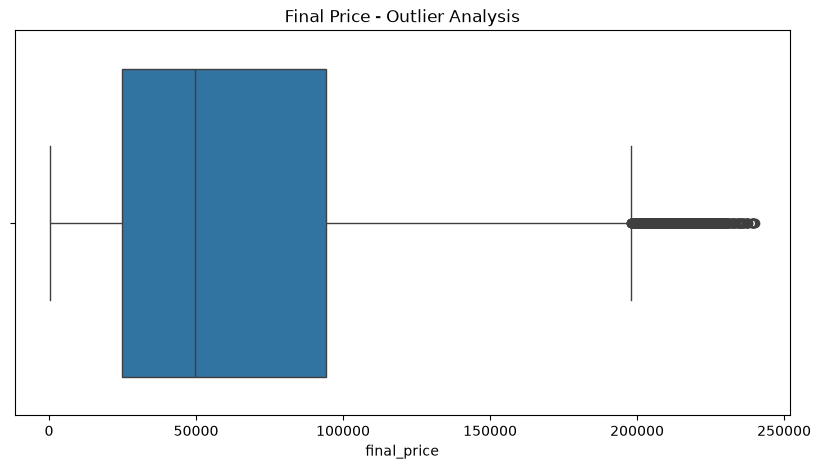

In [120]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['final_price'])
plt.title('Final Price - Outlier Analysis')
plt.show()

# Final price IQR outliers

In [121]:
Q1 = df['final_price'].quantile(.25)
Q3 = df['final_price'].quantile(.75)
IQR = Q3 - Q1

print("Outliers:", len(df[(df['final_price'] < Q1-1.5*IQR) | (df['final_price'] > Q3+1.5*IQR)]))

Outliers: 1335


# CATEGORICAL SUMMARY 

In [122]:
cat_cols = df.select_dtypes(include=['object','str']).columns
df[cat_cols].nunique()

customer_id            100000
gender                      2
city                       10
state                       9
customer_segment            3
order_id               100000
product_category            6
product_subcategory        21
payment_method              4
shipping_type               2
return_status               2
dtype: int64

# Category Frequency Summary

In [123]:
for col in cat_cols:
    print('\n', col)
    print(df[col].value_counts())


 customer_id
customer_id
C10000     1
C10001     1
C10002     1
C10003     1
C10004     1
          ..
C109995    1
C109996    1
C109997    1
C109998    1
C109999    1
Name: count, Length: 100000, dtype: int64

 gender
gender
Male      50111
Female    49889
Name: count, dtype: int64

 city
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64

 state
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64

 customer_segment
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64

 order_id
order_id
O50000     1
O50001     1
O50002     1
O50003     1
O50004     1
          ..
O149995    1
O149996    1
O14